# 3.0 — Reconstruct Dataset: Combine & Resplit 70:15:15

Combines **all images** from train/val/test into one pool, deduplicates by image hash,
then creates a fresh **stratified 70:15:15** split. Core logic lives in `algear.dataset.resplit`.

## Setup

In [1]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.8 MB/s eta 0:00:00


In [2]:
# @title Mount Drive or clone repo
import os
from pathlib import Path
import sys

!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")

Cloning into 'AlGear'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 125 (delta 16), reused 33 (delta 12), pack-reused 88 (from 1)
Receiving objects: 100% (125/125), 61.86 MiB | 25.45 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Project root: /content/AlGear


In [ ]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = ""

from algear.config import ROBOFLOW_DIR, ROBOFLOW_API_KEY
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")
print(f"Dataset at: {ROBOFLOW_DIR}")

2026-06-22 15:32:14.797 | INFO     | algear.config:<module>:10 - PROJ_ROOT path is: /content/AlGear


API key set: True
Dataset at: /content/AlGear/data/raw/construction-safety-gsnvb


In [4]:
# @title Download dataset (if not already present)
if not ROBOFLOW_DIR.exists():
    from algear.dataset import download_roboflow
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-22 15:32:15.206 | INFO     | algear.dataset:download_roboflow:35 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 4496.23it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-22 15:32:42.302 | SUCCESS  | algear.dataset:download_roboflow:39 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


## 1. Run Resplit

All logic (combine, deduplicate, stratified split, write to disk) is in `algear.dataset.resplit`.

In [5]:
# @title Run resplit (70:15:15)
from algear.dataset import resplit

OUTPUT_DIR = resplit(
    src_dir=ROBOFLOW_DIR,
    output_dir=PROJECT_DIR / "data" / "processed" / "construction-site-safety-resplit",
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42,
)

2026-06-22 15:32:42.317 | INFO     | algear.dataset:resplit:154 - Collecting image-label pairs from all splits...
2026-06-22 15:32:42.815 | INFO     | algear.dataset:resplit:182 - Total unique pairs: 1206, duplicates skipped: 0
2026-06-22 15:32:42.855 | INFO     | algear.dataset:resplit:197 - Unique class signatures: 19
2026-06-22 15:32:42.856 | DEBUG    | algear.dataset:resplit:200 -     517 images — ['helmet', 'person', 'vest']
2026-06-22 15:32:42.856 | DEBUG    | algear.dataset:resplit:200 -     368 images — ['helmet', 'no-vest', 'person']
2026-06-22 15:32:42.856 | DEBUG    | algear.dataset:resplit:200 -     127 images — ['helmet', 'person']
2026-06-22 15:32:42.856 | DEBUG    | algear.dataset:resplit:200 -      59 images — ['helmet', 'no-vest', 'person', 'vest']
2026-06-22 15:32:42.856 | DEBUG    | algear.dataset:resplit:200 -      29 images — ['person']
2026-06-22 15:32:42.856 | DEBUG    | algear.dataset:resplit:200 -      21 images — ['helmet', 'no-helmet', 'no-vest', 'person']
20

## 2. Visualize Class Distribution

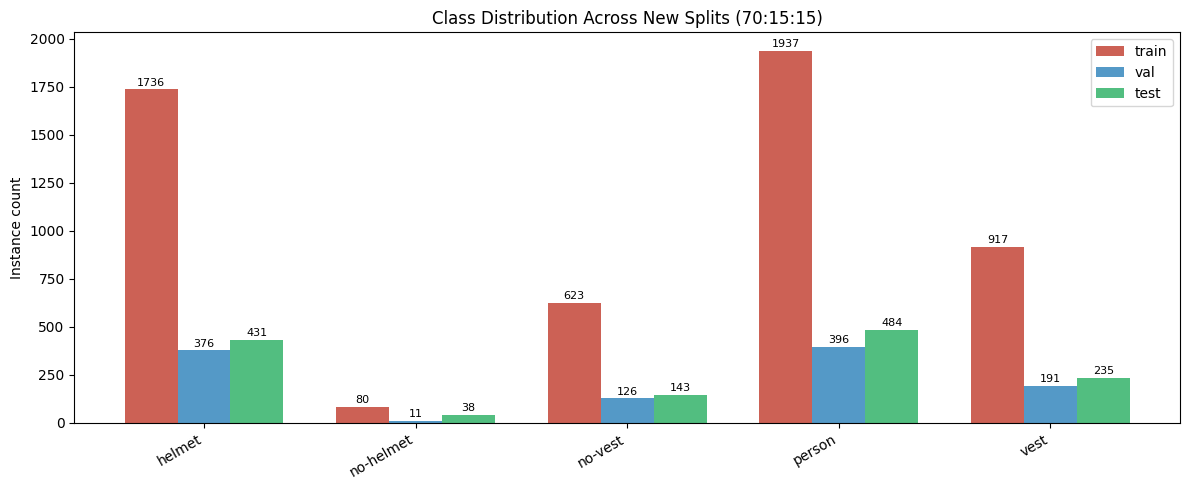

Class              Train      Val     Test
------------------------------------------
helmet              1736      376      431
no-helmet             80       11       38
no-vest              623      126      143
person              1937      396      484
vest                 917      191      235


In [6]:
# @title Plot class distribution across new splits
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import yaml

with open(OUTPUT_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]
num_classes = len(class_names)

def count_instances(lbl_dir: Path) -> Counter:
    c = Counter()
    for lbl in lbl_dir.glob("*.txt"):
        with open(lbl) as f:
            for line in f:
                c[int(line.strip().split()[0])] += 1
    return c

split_counts = {}
for split_name in ["train", "val", "test"]:
    split_counts[split_name] = count_instances(OUTPUT_DIR / split_name / "labels")

names = [class_names[i] for i in range(num_classes)]
x = np.arange(num_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (split_name, color) in enumerate([("train", "#c0392b"), ("val", "#2980b9"), ("test", "#27ae60")]):
    counts = [split_counts[split_name].get(c, 0) for c in range(num_classes)]
    bars = ax.bar(x + i * width, counts, width, label=split_name, color=color, alpha=0.8)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(c), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylabel("Instance count")
ax.set_title("Class Distribution Across New Splits (70:15:15)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'Class':<15s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 42)
for cls_id in range(num_classes):
    t = split_counts["train"].get(cls_id, 0)
    v = split_counts["val"].get(cls_id, 0)
    te = split_counts["test"].get(cls_id, 0)
    print(f"{class_names[cls_id]:<15s} {t:>8d} {v:>8d} {te:>8d}")

## 3. Usage

Use the resplit dataset in training:

```python
from algear.modeling.train import train_yolov8

results = train_yolov8(
    data_yaml=OUTPUT_DIR / "data.yaml",
    model_name="yolov8s.pt",
    name="baseline-resplit",
    epochs=50,
    device="0",
)
```